In [2]:
import pandas as pd
import numpy as np
import gc

print("="*80)
print("DATASET CLEANING - REMOVE USELESS FEATURES AND INVALID LABELS")
print("="*80)

# ================== CONFIGURATION ==================
input_file = "archive/full_df.csv"
output_file = "archive/full_df_cleaned.csv"
chunksize = 50000

# ================== FEATURES TO REMOVE ==================
features_to_remove = [
    # Zero importance features
    'Bwd PSH Flags',
    'Bwd URG Flags',
    'Fwd Pkts/b Avg',
    'Fwd Blk Rate Avg',
    'Bwd Byts/b Avg',
    'Bwd Pkts/b Avg',
    'Bwd Blk Rate Avg',
    'Fwd Byts/b Avg',

    # Identifiers (not real features)
    'Flow ID',
    'Src IP',
    'Dst IP',

    # Near-zero importance (<0.05%)
    'CWE Flag Count',
    'Fwd URG Flags',
    'Pkt Len Min',
    'Active Std',
    'Fwd PSH Flags',
    'Idle Std',
    'SYN Flag Cnt',
    'FIN Flag Cnt',
    'Bwd Pkt Len Min',
    'Active Mean',
    'Active Max',
    'Fwd Pkt Len Min',
    'Active Min',

    # Timestamp (data leakage)
    'Timestamp'
]

# ================== INVALID LABEL ==================
# "Label" is not a valid attack type, it's a mistake in the data
invalid_labels = ['Label']

print(f"\n📋 Configuration:")
print(f"   Input:  {input_file}")
print(f"   Output: {output_file}")
print(f"   Features to remove: {len(features_to_remove)}")
print(f"   Invalid labels to remove: {invalid_labels}")

# ================== FIRST PASS: GET COLUMN NAMES ==================
print(f"\n🔄 Reading first chunk to get column names...")
first_chunk = pd.read_csv(input_file, nrows=1000)
all_columns = first_chunk.columns.tolist()

print(f"\n✅ Original dataset has {len(all_columns)} columns")

# ================== CHECK WHICH FEATURES EXIST ==================
features_to_remove_existing = [f for f in features_to_remove if f in all_columns]
features_not_found = [f for f in features_to_remove if f not in all_columns]

if features_not_found:
    print(f"\n⚠️  Features not found in dataset (skipping):")
    for f in features_not_found:
        print(f"   - {f}")

print(f"\n✅ Will remove {len(features_to_remove_existing)} features")

# ================== COLUMNS TO KEEP ==================
columns_to_keep = [col for col in all_columns if col not in features_to_remove_existing]

print(f"\n📊 Cleaned dataset will have {len(columns_to_keep)} columns:")
print(f"   Original: {len(all_columns)} columns")
print(f"   Removed:  {len(features_to_remove_existing)} columns")
print(f"   Kept:     {len(columns_to_keep)} columns")

# ================== PROCESS AND SAVE DATASET ==================
print(f"\n" + "="*80)
print("PROCESSING DATASET - REMOVING FEATURES AND INVALID LABELS")
print("="*80)

total_rows_read = 0
total_rows_kept = 0
total_rows_removed = 0
first_write = True

for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"   Chunk {i+1}... (processed {total_rows_read:,} rows, kept {total_rows_kept:,})")

    total_rows_read += len(chunk)

    # Remove invalid labels
    original_len = len(chunk)
    chunk = chunk[~chunk['Label'].isin(invalid_labels)]
    rows_removed = original_len - len(chunk)
    total_rows_removed += rows_removed

    # Keep only selected columns
    chunk_cleaned = chunk[columns_to_keep]

    # Write to CSV
    if first_write:
        chunk_cleaned.to_csv(output_file, index=False, mode='w')
        first_write = False
    else:
        chunk_cleaned.to_csv(output_file, index=False, mode='a', header=False)

    total_rows_kept += len(chunk_cleaned)

    # Free memory
    del chunk, chunk_cleaned
    gc.collect()

# ================== SUMMARY ==================
print(f"\n" + "="*80)
print("CLEANING COMPLETE!")
print("="*80)

print(f"\n📊 Summary:")
print(f"   Total rows read:         {total_rows_read:,}")
print(f"   Rows with invalid labels: {total_rows_removed:,}")
print(f"   Rows kept:               {total_rows_kept:,}")
print(f"   Columns removed:         {len(features_to_remove_existing)}")
print(f"   Final columns:           {len(columns_to_keep)}")

print(f"\n✅ Cleaned dataset saved to: {output_file}")

# ================== VERIFICATION ==================
print(f"\n" + "="*80)
print("VERIFICATION - CHECKING CLEANED DATASET")
print("="*80)

print(f"\n🔄 Reading cleaned dataset to verify...")

# Check first few rows
sample = pd.read_csv(output_file, nrows=10000)

print(f"\n✅ Cleaned dataset verification:")
print(f"   Columns: {len(sample.columns)}")
print(f"   Sample rows: {len(sample)}")

# Check labels
unique_labels = sample['Label'].unique()
print(f"\n✅ Unique labels in cleaned dataset ({len(unique_labels)}):")
for label in sorted(unique_labels):
    count = (sample['Label'] == label).sum()
    print(f"   - {label}: {count:,} samples (in first 10k rows)")

# Check removed features
print(f"\n✅ Verification - removed features are gone:")
missing_features = [f for f in features_to_remove_existing if f in sample.columns]
if missing_features:
    print(f"   ❌ ERROR: These features should be removed but still exist:")
    for f in missing_features:
        print(f"      - {f}")
else:
    print(f"   ✅ All unwanted features successfully removed!")

# Check for 'Label' in Label column
if 'Label' in unique_labels:
    print(f"\n   ❌ WARNING: Invalid label 'Label' still exists in data!")
else:
    print(f"\n   ✅ Invalid label 'Label' successfully removed!")

print(f"\n" + "="*80)
print("✅ DATASET CLEANING COMPLETE!")
print(f"Use this file for training: {output_file}")
print("="*80)


DATASET CLEANING - REMOVE USELESS FEATURES AND INVALID LABELS

📋 Configuration:
   Input:  archive/full_df.csv
   Output: archive/full_df_cleaned.csv
   Features to remove: 25
   Invalid labels to remove: ['Label']

🔄 Reading first chunk to get column names...

✅ Original dataset has 84 columns

✅ Will remove 25 features

📊 Cleaned dataset will have 59 columns:
   Original: 84 columns
   Removed:  25 columns
   Kept:     59 columns

PROCESSING DATASET - REMOVING FEATURES AND INVALID LABELS
   Chunk 1... (processed 0 rows, kept 0)
   Chunk 21... (processed 1,000,000 rows, kept 1,000,000)
   Chunk 41... (processed 2,000,000 rows, kept 2,000,000)
   Chunk 61... (processed 3,000,000 rows, kept 3,000,000)


C:\Users\ziedd\AppData\Local\Temp\ipykernel_7744\3345003532.py:96: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
C:\Users\ziedd\AppData\Local\Temp\ipykernel_7744\3345003532.py:96: DtypeWarning: Columns (80,81,83) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):


   Chunk 81... (processed 4,000,000 rows, kept 3,999,999)
   Chunk 101... (processed 5,000,000 rows, kept 4,999,999)
   Chunk 121... (processed 6,000,000 rows, kept 5,999,999)
   Chunk 141... (processed 7,000,000 rows, kept 6,999,999)
   Chunk 161... (processed 8,000,000 rows, kept 7,999,999)
   Chunk 181... (processed 9,000,000 rows, kept 8,999,999)
   Chunk 201... (processed 10,000,000 rows, kept 9,999,999)
   Chunk 221... (processed 11,000,000 rows, kept 10,999,999)


C:\Users\ziedd\AppData\Local\Temp\ipykernel_7744\3345003532.py:96: DtypeWarning: Columns (80,81,83) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):


   Chunk 241... (processed 12,000,000 rows, kept 11,999,999)
   Chunk 261... (processed 13,000,000 rows, kept 12,999,999)
   Chunk 281... (processed 14,000,000 rows, kept 13,999,999)


C:\Users\ziedd\AppData\Local\Temp\ipykernel_7744\3345003532.py:96: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
C:\Users\ziedd\AppData\Local\Temp\ipykernel_7744\3345003532.py:96: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
C:\Users\ziedd\AppData\Local\Temp\ipykernel_7744\3345003532.py:96: Dty

   Chunk 301... (processed 15,000,000 rows, kept 14,999,954)


C:\Users\ziedd\AppData\Local\Temp\ipykernel_7744\3345003532.py:96: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):


   Chunk 321... (processed 16,000,000 rows, kept 15,999,941)

CLEANING COMPLETE!

📊 Summary:
   Total rows read:         16,233,002
   Rows with invalid labels: 59
   Rows kept:               16,232,943
   Columns removed:         25
   Final columns:           59

✅ Cleaned dataset saved to: archive/full_df_cleaned.csv

VERIFICATION - CHECKING CLEANED DATASET

🔄 Reading cleaned dataset to verify...

✅ Cleaned dataset verification:
   Columns: 59
   Sample rows: 10000

✅ Unique labels in cleaned dataset (2):
   - Benign: 96 samples (in first 10k rows)
   - FTP-BruteForce: 9,904 samples (in first 10k rows)

✅ Verification - removed features are gone:
   ✅ All unwanted features successfully removed!

   ✅ Invalid label 'Label' successfully removed!

✅ DATASET CLEANING COMPLETE!
Use this file for training: archive/full_df_cleaned.csv


In [3]:
# ================== FULL VERIFICATION ==================
print(f"\n" + "="*80)
print("FULL DATASET VERIFICATION")
print("="*80)

print(f"\n🔄 Counting all rows in cleaned dataset...")
total_cleaned_rows = 0
all_labels_found = set()

for i, chunk in enumerate(pd.read_csv(output_file, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"   Verifying chunk {i+1}... ({total_cleaned_rows:,} rows)")
    total_cleaned_rows += len(chunk)
    all_labels_found.update(chunk['Label'].unique())

print(f"\n✅ Full cleaned dataset:")
print(f"   Total rows: {total_cleaned_rows:,}")
print(f"   Total columns: {len(pd.read_csv(output_file, nrows=1).columns)}")
print(f"   Unique labels: {len(all_labels_found)}")

print(f"\n📋 All labels in cleaned dataset:")
for label in sorted(all_labels_found):
    print(f"   - {label}")

# Verify no invalid label exists
if 'Label' in all_labels_found:
    print(f"\n❌ ERROR: Invalid 'Label' still in dataset!")
else:
    print(f"\n✅ Invalid 'Label' successfully removed from ALL chunks!")

# Compare with original
print(f"\n📊 Comparison:")
print(f"   Original rows:     {total_rows_read:,}")
print(f"   Cleaned rows:      {total_cleaned_rows:,}")
print(f"   Rows removed:      {total_rows_read - total_cleaned_rows:,}")
print(f"   Match expected:    {total_cleaned_rows == total_rows_kept}")


FULL DATASET VERIFICATION

🔄 Counting all rows in cleaned dataset...
   Verifying chunk 1... (0 rows)
   Verifying chunk 21... (1,000,000 rows)
   Verifying chunk 41... (2,000,000 rows)
   Verifying chunk 61... (3,000,000 rows)
   Verifying chunk 81... (4,000,000 rows)
   Verifying chunk 101... (5,000,000 rows)
   Verifying chunk 121... (6,000,000 rows)
   Verifying chunk 141... (7,000,000 rows)
   Verifying chunk 161... (8,000,000 rows)
   Verifying chunk 181... (9,000,000 rows)
   Verifying chunk 201... (10,000,000 rows)
   Verifying chunk 221... (11,000,000 rows)
   Verifying chunk 241... (12,000,000 rows)
   Verifying chunk 261... (13,000,000 rows)
   Verifying chunk 281... (14,000,000 rows)
   Verifying chunk 301... (15,000,000 rows)
   Verifying chunk 321... (16,000,000 rows)

✅ Full cleaned dataset:
   Total rows: 16,232,943
   Total columns: 59
   Unique labels: 15

📋 All labels in cleaned dataset:
   - Benign
   - Bot
   - Brute Force -Web
   - Brute Force -XSS
   - DDOS atta

MISSING VALUES ANALYSIS - CLEANED DATASET

🔄 Scanning cleaned dataset for missing values...
   Processing chunk 1... (0 rows)
   Processing chunk 21... (1,000,000 rows)
   Processing chunk 41... (2,000,000 rows)
   Processing chunk 61... (3,000,000 rows)
   Processing chunk 81... (4,000,000 rows)
   Processing chunk 101... (5,000,000 rows)
   Processing chunk 121... (6,000,000 rows)
   Processing chunk 141... (7,000,000 rows)
   Processing chunk 161... (8,000,000 rows)
   Processing chunk 181... (9,000,000 rows)
   Processing chunk 201... (10,000,000 rows)
   Processing chunk 221... (11,000,000 rows)
   Processing chunk 241... (12,000,000 rows)
   Processing chunk 261... (13,000,000 rows)
   Processing chunk 281... (14,000,000 rows)
   Processing chunk 301... (15,000,000 rows)
   Processing chunk 321... (16,000,000 rows)

✅ Scanned 16,232,943 total rows
✅ Total columns: 59

✅ Missing values analysis saved to 'missing_values_analysis.csv'

MISSING VALUES SUMMARY

📊 Overall Statistics:
 

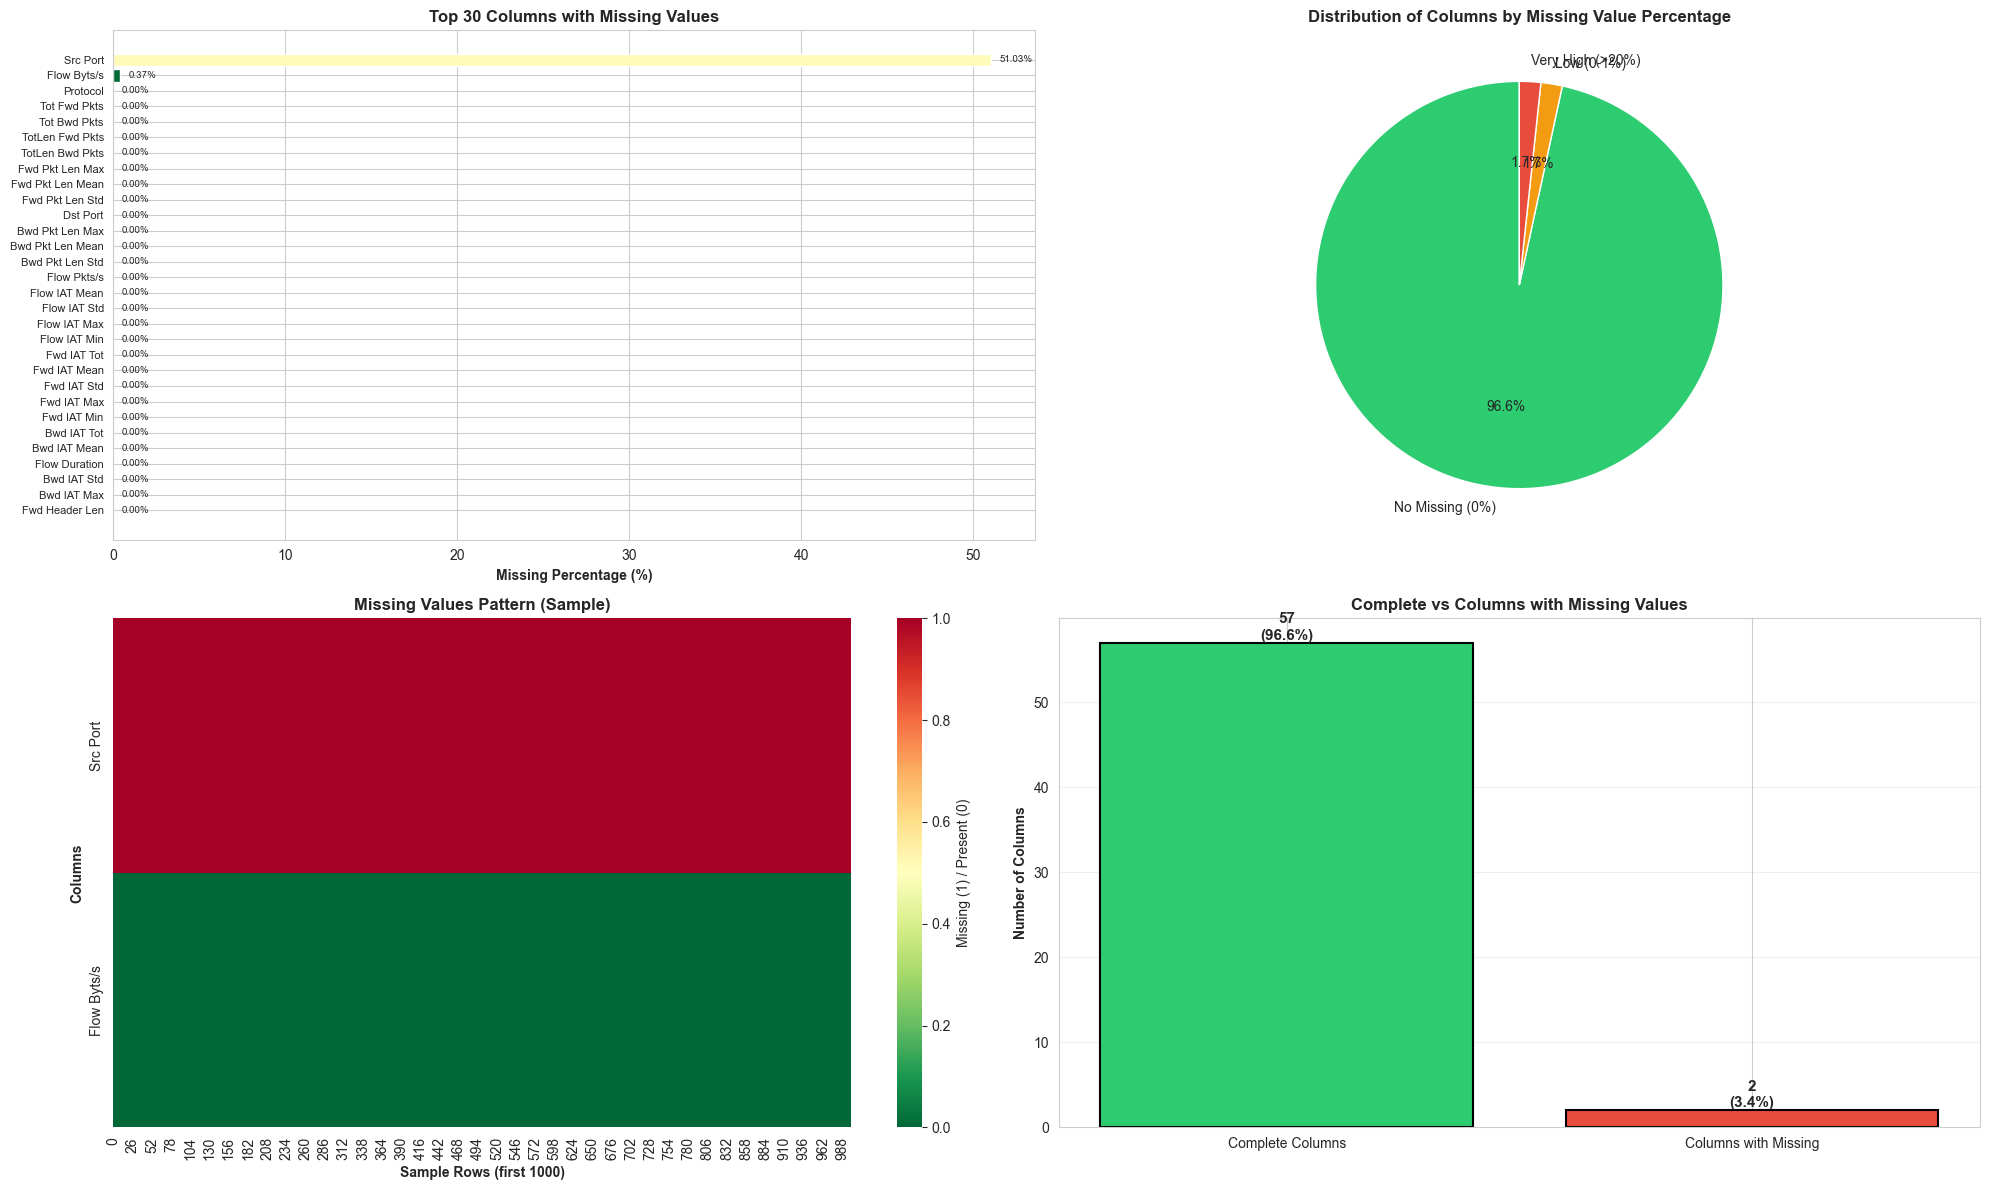


DETAILED STATISTICS

📊 Missing Values by Category:
   No missing (0%):      57 columns
   Low (0-1%):           1 columns
   Medium (1-5%):        0 columns
   High (5-20%):         0 columns
   Very High (>20%):     1 columns

⚠️  RECOMMENDATION:
   - 1 columns have >20% missing values
   - Consider removing these columns or using imputation

   Columns with >20% missing:
      • Src Port: 51.03%

✅ MISSING VALUES ANALYSIS COMPLETE!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("MISSING VALUES ANALYSIS - CLEANED DATASET")
print("="*80)

# ================== CONFIGURATION ==================
file_path = "archive/full_df_cleaned.csv"
chunksize = 50000

# ================== SCAN DATASET FOR MISSING VALUES ==================
print("\n🔄 Scanning cleaned dataset for missing values...")

total_rows = 0
column_names = []
missing_counts = {}
first_chunk = True

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"   Processing chunk {i+1}... ({total_rows:,} rows)")

    if first_chunk:
        column_names = chunk.columns.tolist()
        for col in column_names:
            missing_counts[col] = 0
        first_chunk = False

    # Count missing values in this chunk
    for col in column_names:
        missing_counts[col] += chunk[col].isna().sum()

    total_rows += len(chunk)

print(f"\n✅ Scanned {total_rows:,} total rows")
print(f"✅ Total columns: {len(column_names)}")

# ================== CREATE MISSING VALUES DATAFRAME ==================
missing_df = pd.DataFrame({
    'Column': column_names,
    'Missing_Count': [missing_counts[col] for col in column_names],
    'Total_Rows': total_rows
})

missing_df['Missing_Percentage'] = (missing_df['Missing_Count'] / missing_df['Total_Rows'] * 100).round(2)
missing_df = missing_df.sort_values('Missing_Count', ascending=False)

# ================== SAVE MISSING VALUES REPORT ==================
missing_df.to_csv('missing_values_analysis.csv', index=False)
print(f"\n✅ Missing values analysis saved to 'missing_values_analysis.csv'")

# ================== DISPLAY SUMMARY ==================
print("\n" + "="*80)
print("MISSING VALUES SUMMARY")
print("="*80)

total_missing = missing_df['Missing_Count'].sum()
total_cells = total_rows * len(column_names)
overall_missing_pct = (total_missing / total_cells * 100)

print(f"\n📊 Overall Statistics:")
print(f"   Total rows:           {total_rows:,}")
print(f"   Total columns:        {len(column_names)}")
print(f"   Total cells:          {total_cells:,}")
print(f"   Total missing values: {total_missing:,}")
print(f"   Overall missing %:    {overall_missing_pct:.2f}%")

# Columns with missing values
columns_with_missing = missing_df[missing_df['Missing_Count'] > 0]
print(f"\n📊 Columns with missing values: {len(columns_with_missing)}")

if len(columns_with_missing) > 0:
    print("\n📋 TOP 20 COLUMNS WITH MOST MISSING VALUES:")
    print("="*80)
    print(columns_with_missing.head(20).to_string(index=False))
else:
    print("\n✅ NO MISSING VALUES FOUND IN THE DATASET!")

# ================== VISUALIZATIONS ==================
print("\n🎨 Generating visualizations...")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create figure with subplots
fig = plt.figure(figsize=(20, 12))

# ================== PLOT 1: BAR CHART - TOP 30 COLUMNS WITH MISSING VALUES ==================
ax1 = plt.subplot(2, 2, 1)
top_30_missing = missing_df.head(30)

if len(columns_with_missing) > 0:
    bars = ax1.barh(range(len(top_30_missing)), top_30_missing['Missing_Percentage'],
                     color=plt.cm.RdYlGn_r(top_30_missing['Missing_Percentage']/100))
    ax1.set_yticks(range(len(top_30_missing)))
    ax1.set_yticklabels(top_30_missing['Column'], fontsize=8)
    ax1.set_xlabel('Missing Percentage (%)', fontsize=10, fontweight='bold')
    ax1.set_title('Top 30 Columns with Missing Values', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()

    # Add percentage labels
    for i, (idx, row) in enumerate(top_30_missing.iterrows()):
        ax1.text(row['Missing_Percentage'] + 0.5, i, f"{row['Missing_Percentage']:.2f}%",
                va='center', fontsize=7)
else:
    ax1.text(0.5, 0.5, 'NO MISSING VALUES', ha='center', va='center',
            fontsize=16, fontweight='bold', transform=ax1.transAxes)
    ax1.set_title('Missing Values by Column', fontsize=12, fontweight='bold')

# ================== PLOT 2: PIE CHART - DISTRIBUTION ==================
ax2 = plt.subplot(2, 2, 2)

if len(columns_with_missing) > 0:
    # Categorize columns by missing percentage
    categories = {
        'No Missing (0%)': len(missing_df[missing_df['Missing_Percentage'] == 0]),
        'Low (0-1%)': len(missing_df[(missing_df['Missing_Percentage'] > 0) & (missing_df['Missing_Percentage'] <= 1)]),
        'Medium (1-5%)': len(missing_df[(missing_df['Missing_Percentage'] > 1) & (missing_df['Missing_Percentage'] <= 5)]),
        'High (5-20%)': len(missing_df[(missing_df['Missing_Percentage'] > 5) & (missing_df['Missing_Percentage'] <= 20)]),
        'Very High (>20%)': len(missing_df[missing_df['Missing_Percentage'] > 20])
    }

    # Remove categories with 0 count
    categories = {k: v for k, v in categories.items() if v > 0}

    colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b', '#8b0000']
    ax2.pie(categories.values(), labels=categories.keys(), autopct='%1.1f%%',
           startangle=90, colors=colors[:len(categories)])
    ax2.set_title('Distribution of Columns by Missing Value Percentage', fontsize=12, fontweight='bold')
else:
    ax2.pie([100], labels=['No Missing Values'], autopct='%1.1f%%',
           startangle=90, colors=['#2ecc71'])
    ax2.set_title('Distribution of Columns by Missing Value Percentage', fontsize=12, fontweight='bold')

# ================== PLOT 3: HEATMAP - MISSING VALUES PATTERN ==================
ax3 = plt.subplot(2, 2, 3)

if len(columns_with_missing) > 0:
    # Sample data for heatmap visualization (first 1000 rows)
    sample_data = pd.read_csv(file_path, nrows=1000)

    # Get only columns with missing values
    cols_with_missing = columns_with_missing.head(20)['Column'].tolist()
    cols_with_missing_in_sample = [col for col in cols_with_missing if col in sample_data.columns]

    if cols_with_missing_in_sample:
        # Create binary matrix (1 = missing, 0 = not missing)
        missing_matrix = sample_data[cols_with_missing_in_sample].isna().astype(int)

        sns.heatmap(missing_matrix.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing (1) / Present (0)'},
                   ax=ax3, yticklabels=cols_with_missing_in_sample)
        ax3.set_xlabel('Sample Rows (first 1000)', fontsize=10, fontweight='bold')
        ax3.set_ylabel('Columns', fontsize=10, fontweight='bold')
        ax3.set_title('Missing Values Pattern (Sample)', fontsize=12, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'NO MISSING VALUES IN SAMPLE', ha='center', va='center',
                fontsize=14, fontweight='bold', transform=ax3.transAxes)
else:
    ax3.text(0.5, 0.5, 'NO MISSING VALUES', ha='center', va='center',
            fontsize=14, fontweight='bold', transform=ax3.transAxes)
    ax3.set_title('Missing Values Pattern', fontsize=12, fontweight='bold')

# ================== PLOT 4: COUNT PLOT - MISSING VS COMPLETE ==================
ax4 = plt.subplot(2, 2, 4)

complete_count = len(missing_df[missing_df['Missing_Count'] == 0])
missing_count = len(missing_df[missing_df['Missing_Count'] > 0])

bars = ax4.bar(['Complete Columns', 'Columns with Missing'],
               [complete_count, missing_count],
               color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)

ax4.set_ylabel('Number of Columns', fontsize=10, fontweight='bold')
ax4.set_title('Complete vs Columns with Missing Values', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(column_names)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# ================== SAVE AND SHOW ==================
plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=300, bbox_inches='tight')
print(f"✅ Visualization saved to 'missing_values_analysis.png'")

plt.show()

# ================== ADDITIONAL STATISTICS ==================
print("\n" + "="*80)
print("DETAILED STATISTICS")
print("="*80)

if len(columns_with_missing) > 0:
    print(f"\n📊 Missing Values by Category:")
    print(f"   No missing (0%):      {len(missing_df[missing_df['Missing_Percentage'] == 0]):,} columns")
    print(f"   Low (0-1%):           {len(missing_df[(missing_df['Missing_Percentage'] > 0) & (missing_df['Missing_Percentage'] <= 1)]):,} columns")
    print(f"   Medium (1-5%):        {len(missing_df[(missing_df['Missing_Percentage'] > 1) & (missing_df['Missing_Percentage'] <= 5)]):,} columns")
    print(f"   High (5-20%):         {len(missing_df[(missing_df['Missing_Percentage'] > 5) & (missing_df['Missing_Percentage'] <= 20)]):,} columns")
    print(f"   Very High (>20%):     {len(missing_df[missing_df['Missing_Percentage'] > 20]):,} columns")

    print(f"\n⚠️  RECOMMENDATION:")
    high_missing = missing_df[missing_df['Missing_Percentage'] > 20]
    if len(high_missing) > 0:
        print(f"   - {len(high_missing)} columns have >20% missing values")
        print(f"   - Consider removing these columns or using imputation")
        print(f"\n   Columns with >20% missing:")
        for idx, row in high_missing.iterrows():
            print(f"      • {row['Column']}: {row['Missing_Percentage']:.2f}%")
    else:
        print(f"   ✅ No columns with >20% missing values")
        print(f"   ✅ Dataset quality is good!")
else:
    print(f"\n✅ PERFECT! No missing values in the dataset!")
    print(f"   The cleaned dataset has complete data for all {total_rows:,} rows")

print("\n" + "="*80)
print("✅ MISSING VALUES ANALYSIS COMPLETE!")
print("="*80)

In [6]:
import pandas as pd
import numpy as np
import gc

print("="*80)
print("REMOVING HIGH MISSING VALUE COLUMNS")
print("="*80)

# ================== CONFIGURATION ==================
input_file = "archive/full_df_cleaned.csv"
output_file = "archive/full_df_cleaned_v2.csv"
chunksize = 50000

# Columns to remove due to high missing values (>20%)
columns_to_remove = ['Src Port']  # 51% missing

print(f"\n⚠️  Removing columns with >20% missing values:")
for col in columns_to_remove:
    print(f"   - {col}")

# ================== PROCESS DATASET ==================
print(f"\n🔄 Processing dataset...")

total_rows = 0
first_write = True

for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"   Chunk {i+1}... ({total_rows:,} rows)")

    # Remove columns with high missing values
    chunk_cleaned = chunk.drop(columns=columns_to_remove, errors='ignore')

    # Handle Flow Byts/s (0.37% missing - can impute)
    if 'Flow Byts/s' in chunk_cleaned.columns:
        # Fill missing with 0 (if no bytes transferred)
        chunk_cleaned['Flow Byts/s'] = chunk_cleaned['Flow Byts/s'].fillna(0)

    # Write to CSV
    if first_write:
        chunk_cleaned.to_csv(output_file, index=False, mode='w')
        first_write = False
    else:
        chunk_cleaned.to_csv(output_file, index=False, mode='a', header=False)

    total_rows += len(chunk)
    del chunk, chunk_cleaned
    gc.collect()

print(f"\n✅ Processed {total_rows:,} rows")

# ================== VERIFY ==================
print(f"\n🔄 Verifying cleaned dataset...")
sample = pd.read_csv(output_file, nrows=10000)

print(f"\n📊 Final Dataset:")
print(f"   Columns: {len(sample.columns)}")
print(f"   Sample rows: {len(sample)}")

# Check for missing values
missing_check = sample.isna().sum()
columns_with_missing = missing_check[missing_check > 0]

if len(columns_with_missing) > 0:
    print(f"\n⚠️  Remaining missing values:")
    for col, count in columns_with_missing.items():
        pct = (count / len(sample)) * 100
        print(f"   - {col}: {count} ({pct:.2f}%)")
else:
    print(f"\n✅ NO MISSING VALUES!")

print(f"\n✅ Cleaned dataset v2 saved to: {output_file}")

print("\n" + "="*80)
print("✅ DATASET CLEANING COMPLETE!")
print("Use this file for baseline: archive/full_df_cleaned_v2.csv")
print("="*80)


REMOVING HIGH MISSING VALUE COLUMNS

⚠️  Removing columns with >20% missing values:
   - Src Port

🔄 Processing dataset...
   Chunk 1... (0 rows)
   Chunk 21... (1,000,000 rows)
   Chunk 41... (2,000,000 rows)
   Chunk 61... (3,000,000 rows)
   Chunk 81... (4,000,000 rows)
   Chunk 101... (5,000,000 rows)
   Chunk 121... (6,000,000 rows)
   Chunk 141... (7,000,000 rows)
   Chunk 161... (8,000,000 rows)
   Chunk 181... (9,000,000 rows)
   Chunk 201... (10,000,000 rows)
   Chunk 221... (11,000,000 rows)
   Chunk 241... (12,000,000 rows)
   Chunk 261... (13,000,000 rows)
   Chunk 281... (14,000,000 rows)
   Chunk 301... (15,000,000 rows)
   Chunk 321... (16,000,000 rows)

✅ Processed 16,232,943 rows

🔄 Verifying cleaned dataset...

📊 Final Dataset:
   Columns: 58
   Sample rows: 10000

✅ NO MISSING VALUES!

✅ Cleaned dataset v2 saved to: archive/full_df_cleaned_v2.csv

✅ DATASET CLEANING COMPLETE!
Use this file for baseline: archive/full_df_cleaned_v2.csv


PRE-BASELINE ANALYSIS - DOCUMENTATION ONLY

🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷
1. CLASS DISTRIBUTION ANALYSIS (Documentation)
🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷

🔄 Analyzing class distribution...
   Chunk 1... (0 rows)
   Chunk 21... (1,000,000 rows)
   Chunk 41... (2,000,000 rows)
   Chunk 61... (3,000,000 rows)
   Chunk 81... (4,000,000 rows)
   Chunk 101... (5,000,000 rows)
   Chunk 121... (6,000,000 rows)
   Chunk 141... (7,000,000 rows)
   Chunk 161... (8,000,000 rows)
   Chunk 181... (9,000,000 rows)
   Chunk 201... (10,000,000 rows)
   Chunk 221... (11,000,000 rows)
   Chunk 241... (12,000,000 rows)
   Chunk 261... (13,000,000 rows)
   Chunk 281... (14,000,000 rows)
   Chunk 301... (15,000,000 rows)
   Chunk 321... (16,000,000 rows)

📊 CLASS DISTRIBUTION:
                   Class    Count  Percentage
                  Benign 13484708   83.070014
        DDOS attack-HOIC   686012    4.226048
  DDoS attacks-LOIC-HTTP   576191    3.549517
        DoS attacks-Hulk   4619

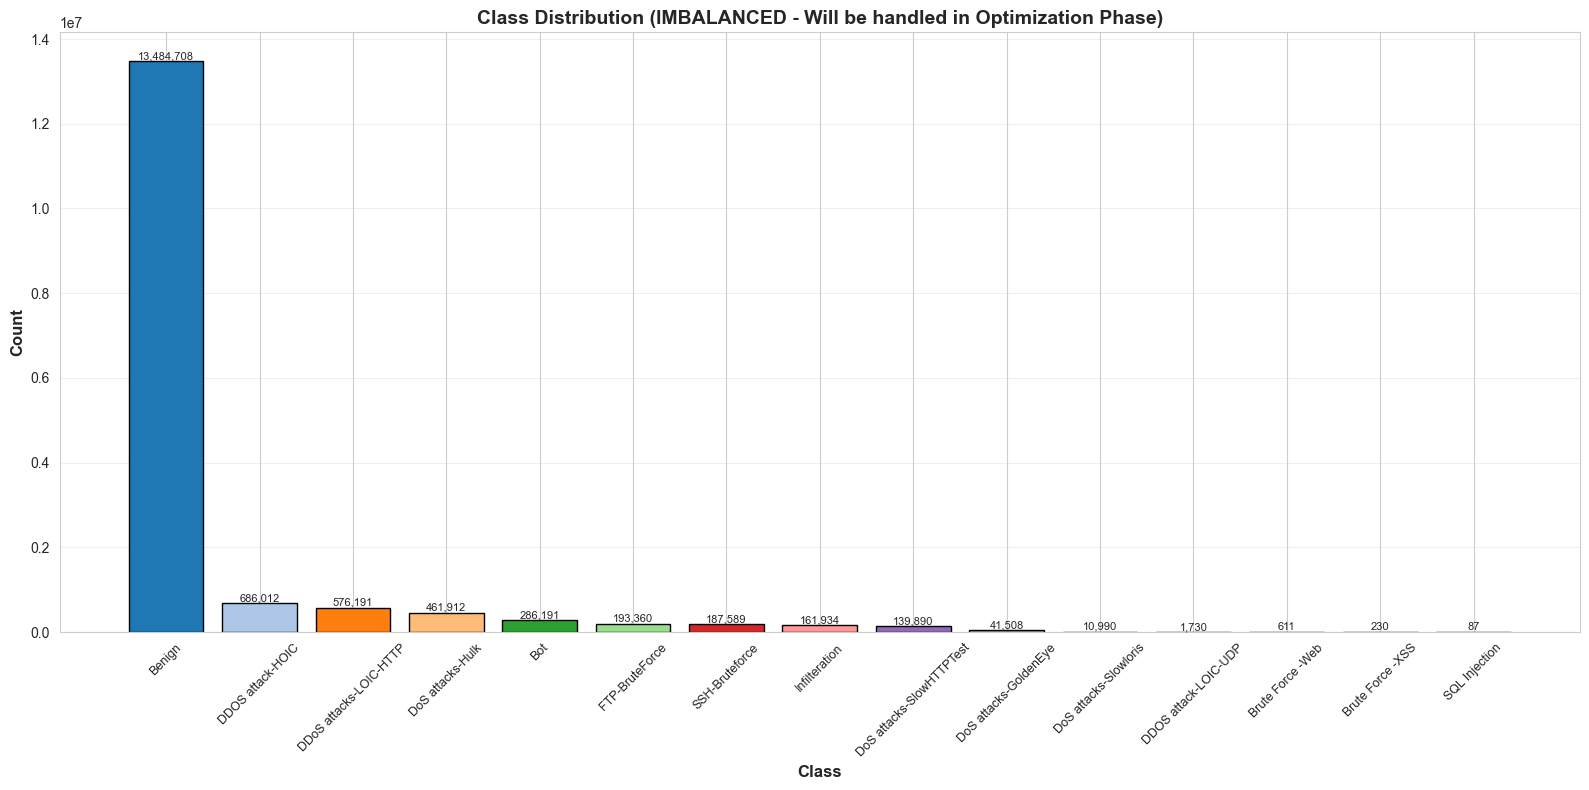


PRE-BASELINE SUMMARY

📊 Dataset:
   Total samples: 16,232,943
   Total classes: 15
   Features: 56

📋 Data Quality:
   Invalid values: YES - MUST FIX!
   Class imbalance: YES
   → Imbalance will be handled in OPTIMIZATION phase

✅ Ready for BASELINE if:
   ❌ No inf/-inf/nan values
   ✅ All features numeric (except Label)

⚠️  CLEANING REQUIRED - Run This Code:

# CLEANING CODE TO FIX INVALID VALUES:
import pandas as pd
import numpy as np

input_file = "archive/full_df_cleaned_v2.csv"
output_file = "archive/full_df_cleaned_v3.csv"
chunksize = 50000

first_write = True
total_rows = 0

for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"Cleaning chunk {i+1}... ({total_rows:,} rows)")
    
    # Get numeric columns (exclude Label)
    numeric_cols = chunk.select_dtypes(include=[np.number]).columns
    
    # Replace inf/-inf with nan, then fill with 0
    for col in numeric_cols:
        chunk[col] = chunk[col].replace([np.inf, -np.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

print("="*80)
print("PRE-BASELINE ANALYSIS - DOCUMENTATION ONLY")
print("="*80)

file_path = "archive/full_df_cleaned_v2.csv"
chunksize = 50000

# ================== 1. CLASS DISTRIBUTION (DOCUMENT ONLY) ==================
print("\n" + "🔷"*40)
print("1. CLASS DISTRIBUTION ANALYSIS (Documentation)")
print("🔷"*40)

print("\n🔄 Analyzing class distribution...")
label_counts = {}
total_rows = 0

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"   Chunk {i+1}... ({total_rows:,} rows)")

    for label in chunk['Label'].values:
        label_counts[label] = label_counts.get(label, 0) + 1

    total_rows += len(chunk)

class_dist = pd.DataFrame([
    {'Class': k, 'Count': v, 'Percentage': (v/total_rows)*100}
    for k, v in sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
])

print(f"\n📊 CLASS DISTRIBUTION:")
print("="*80)
print(class_dist.to_string(index=False))

class_dist.to_csv('class_distribution.csv', index=False)

# Check imbalance (DOCUMENT, don't fix)
minority_classes = class_dist[class_dist['Percentage'] < 0.1]
if len(minority_classes) > 0:
    print(f"\n⚠️  IMBALANCE DETECTED: {len(minority_classes)} classes have <0.1% samples")
    print(f"📝 NOTE: This will be handled in OPTIMIZATION phase (class_weight, SMOTE)")
    print(f"📝 BASELINE will train on imbalanced data AS-IS")
else:
    print(f"\n✅ No severe class imbalance")

# ================== 2. INVALID VALUES - MUST FIX ==================
print("\n" + "🔷"*40)
print("2. INVALID VALUES CHECK (Must Clean)")
print("🔷"*40)

print("\n🔄 Checking for inf/-inf/nan in sample...")

# Read a sample to check
sample = pd.read_csv(file_path, nrows=50000)
numeric_cols = sample.select_dtypes(include=[np.number]).columns

has_invalid = False
invalid_summary = []

for col in numeric_cols:
    if col != 'Label':
        inf_count = np.isinf(sample[col]).sum()
        neg_inf_count = (sample[col] == -np.inf).sum()
        nan_count = sample[col].isna().sum()

        if inf_count > 0 or neg_inf_count > 0 or nan_count > 0:
            has_invalid = True
            invalid_summary.append({
                'Column': col,
                'Inf': inf_count,
                'Neg_Inf': neg_inf_count,
                'NaN': nan_count,
                'Total_Invalid': inf_count + neg_inf_count + nan_count
            })

if has_invalid:
    print(f"\n❌ INVALID VALUES FOUND IN SAMPLE!")
    invalid_df = pd.DataFrame(invalid_summary).sort_values('Total_Invalid', ascending=False)
    print(invalid_df.to_string(index=False))
    print(f"\n🔧 YOU MUST CLEAN THESE BEFORE BASELINE!")
    print(f"   Run the cleaning code below...")

    # Save for reference
    invalid_df.to_csv('invalid_values_found.csv', index=False)
else:
    print(f"\n✅ NO invalid values (inf/-inf/nan) found in sample")

# ================== 3. DATA TYPES ==================
print("\n" + "🔷"*40)
print("3. DATA TYPES VERIFICATION")
print("🔷"*40)

sample_check = pd.read_csv(file_path, nrows=1000)
numeric_count = len(sample_check.select_dtypes(include=[np.number]).columns)
non_numeric = sample_check.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n📊 Data Types:")
print(f"   Numeric columns: {numeric_count}")
print(f"   Non-numeric columns: {len(non_numeric)}")

if len(non_numeric) == 1 and 'Label' in non_numeric:
    print(f"   ✅ Only 'Label' is non-numeric (expected)")
elif len(non_numeric) == 0:
    print(f"   ⚠️  'Label' appears to be numeric - check encoding")
else:
    print(f"   ⚠️  Unexpected non-numeric columns: {non_numeric}")

# ================== VISUALIZATION ==================
print("\n🎨 Generating class distribution visualization...")

fig, ax = plt.subplots(figsize=(16, 8))
colors = plt.cm.tab20(range(len(class_dist)))
bars = ax.bar(class_dist['Class'], class_dist['Count'], color=colors, edgecolor='black')
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution (IMBALANCED - Will be handled in Optimization Phase)',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution_imbalanced.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved to 'class_distribution_imbalanced.png'")
plt.show()

# ================== SUMMARY ==================
print("\n" + "="*80)
print("PRE-BASELINE SUMMARY")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   Total samples: {total_rows:,}")
print(f"   Total classes: {len(label_counts)}")
print(f"   Features: {numeric_count - 1 if 'Label' in non_numeric else numeric_count}")

print(f"\n📋 Data Quality:")
print(f"   Invalid values: {'YES - MUST FIX!' if has_invalid else 'NO'}")
print(f"   Class imbalance: {'YES' if len(minority_classes) > 0 else 'NO'}")
if len(minority_classes) > 0:
    print(f"   → Imbalance will be handled in OPTIMIZATION phase")

print(f"\n✅ Ready for BASELINE if:")
print(f"   {'✅' if not has_invalid else '❌'} No inf/-inf/nan values")
print(f"   {'✅' if len(non_numeric) <= 1 else '❌'} All features numeric (except Label)")

if has_invalid:
    print(f"\n" + "="*80)
    print("⚠️  CLEANING REQUIRED - Run This Code:")
    print("="*80)
# CLEANING CODE TO FIX INVALID VALUES:


In [10]:
import pandas as pd
import numpy as np

input_file = "archive/full_df_cleaned_v2.csv"
output_file = "archive/full_df_cleaned_v3.csv"
chunksize = 50000

first_write = True
total_rows = 0

for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"Cleaning chunk {i+1}... ({total_rows:,} rows)")

    # Get numeric columns (exclude Label)
    numeric_cols = chunk.select_dtypes(include=[np.number]).columns

    # Replace inf/-inf with nan, then fill with 0
    for col in numeric_cols:
        chunk[col] = chunk[col].replace([np.inf, -np.inf], np.nan)
        chunk[col] = chunk[col].fillna(0)

    # Write
    if first_write:
        chunk.to_csv(output_file, index=False, mode='w')
        first_write = False
    else:
        chunk.to_csv(output_file, index=False, mode='a', header=False)

    total_rows += len(chunk)

print(f"✅ Cleaned {total_rows:,} rows")
print(f"✅ Use: {output_file}")



Cleaning chunk 1... (0 rows)
Cleaning chunk 21... (1,000,000 rows)
Cleaning chunk 41... (2,000,000 rows)
Cleaning chunk 61... (3,000,000 rows)
Cleaning chunk 81... (4,000,000 rows)
Cleaning chunk 101... (5,000,000 rows)
Cleaning chunk 121... (6,000,000 rows)
Cleaning chunk 141... (7,000,000 rows)
Cleaning chunk 161... (8,000,000 rows)
Cleaning chunk 181... (9,000,000 rows)
Cleaning chunk 201... (10,000,000 rows)
Cleaning chunk 221... (11,000,000 rows)
Cleaning chunk 241... (12,000,000 rows)
Cleaning chunk 261... (13,000,000 rows)
Cleaning chunk 281... (14,000,000 rows)
Cleaning chunk 301... (15,000,000 rows)
Cleaning chunk 321... (16,000,000 rows)
✅ Cleaned 16,232,943 rows
✅ Use: archive/full_df_cleaned_v3.csv


In [11]:

input_file = "archive/full_df_cleaned_v3.csv"
output_file = "archive/full_df_binary_labels.csv"
chunksize = 50000

first_write = True
total_rows = 0
label_counts = {}

for i, chunk in enumerate(pd.read_csv(input_file, chunksize=chunksize)):
    if i % 20 == 0:
        print(f"Processing chunk {i+1}... ({total_rows:,} rows)")

    # Create binary label column
    # 0 = Benign, 1 = Attack
    chunk['Label_Binary'] = chunk['Label'].apply(
        lambda x: 0 if str(x).lower() in ['benign', 'normal'] else 1
    )

    # Count label distribution (optional, for verification)
    for label in chunk['Label'].value_counts().items():
        label_counts[label[0]] = label_counts.get(label[0], 0) + label[1]

    # Write to output
    if first_write:
        chunk.to_csv(output_file, index=False, mode='w')
        first_write = False
    else:
        chunk.to_csv(output_file, index=False, mode='a', header=False)

    total_rows += len(chunk)

print(f"\n✅ Processed {total_rows:,} rows")
print(f"✅ Output saved to: {output_file}")
print(f"\n📊 Label Distribution:")
for label, count in sorted(label_counts.items()):
    binary = 0 if str(label).lower() in ['benign', 'normal'] else 1
    print(f"  {label}: {count:,} rows → Binary: {binary}")

# Calculate binary distribution
benign_count = sum(count for label, count in label_counts.items()
                   if str(label).lower() in ['benign', 'normal'])
attack_count = total_rows - benign_count
print(f"\n📈 Binary Label Summary:")
print(f"  Benign (0): {benign_count:,} rows ({100*benign_count/total_rows:.2f}%)")
print(f"  Attack (1): {attack_count:,} rows ({100*attack_count/total_rows:.2f}%)")

Processing chunk 1... (0 rows)
Processing chunk 21... (1,000,000 rows)
Processing chunk 41... (2,000,000 rows)
Processing chunk 61... (3,000,000 rows)
Processing chunk 81... (4,000,000 rows)
Processing chunk 101... (5,000,000 rows)
Processing chunk 121... (6,000,000 rows)
Processing chunk 141... (7,000,000 rows)
Processing chunk 161... (8,000,000 rows)
Processing chunk 181... (9,000,000 rows)
Processing chunk 201... (10,000,000 rows)
Processing chunk 221... (11,000,000 rows)
Processing chunk 241... (12,000,000 rows)
Processing chunk 261... (13,000,000 rows)
Processing chunk 281... (14,000,000 rows)
Processing chunk 301... (15,000,000 rows)
Processing chunk 321... (16,000,000 rows)

✅ Processed 16,232,943 rows
✅ Output saved to: archive/full_df_binary_labels.csv

📊 Label Distribution:
  Benign: 13,484,708 rows → Binary: 0
  Bot: 286,191 rows → Binary: 1
  Brute Force -Web: 611 rows → Binary: 1
  Brute Force -XSS: 230 rows → Binary: 1
  DDOS attack-HOIC: 686,012 rows → Binary: 1
  DDOS a